# The project in one figure

Three panels:

- **(a)** the confound — aerosol cleanup reaches every warming level earlier, so year-matched
  comparisons mix the GMST offset with the pattern response. GWL matching removes it.
- **(b)** the result — at matched GWL, the aerosol pathway and the SSP choice reject at the
  test's own false-positive floor (0.057); only overshoot sits above it.
- **(c)** where it breaks — same model (GISS-E2-1-G), same warming level, same ensemble size:
  the aerosol comparison is flat noise, the rising-vs-declining comparison has spatial structure.

Reads only caches (the zarr product and the KS netCDFs). Output:
`figures/project_overview.png`.

In [1]:
import os, glob, warnings
import numpy as np
import pandas as pd
import xarray as xr
import matplotlib as mpl
import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec
import cartopy.crs as ccrs
import cmocean

import sys
sys.path.insert(0, '/burg-archive/home/mck2199/summer/bcd_me/code')
sys.path.insert(0, '/burg-archive/home/mck2199/summer/bcd_me/path_independence')
from funcs_support import get_params
import ks_tools as kt

dir_list = get_params()
warnings.filterwarnings('ignore', category=FutureWarning)

P        = dir_list['aux'] + 'gwl_timeseries.zarr'
GWL_DIR  = dir_list['aux'] + 'diagnostics/ramip_gwl/'
SCEN_KS  = dir_list['aux'] + 'diagnostics/ks_scenarios/'
out_dir  = dir_list['aux'] + '../figures/'

ALPHA, FLOOR = 0.05, 0.057
RED, BLUE = '#c1272d', '#0000a7'
gmst = xr.open_zarr(P, group='gmst')
gwl  = xr.open_zarr(P, group='gwl')

## Panel data

(a) 10-yr running-mean ensemble-mean GMST per model, both global arms.
(b) land fraction rejecting for every comparison, grouped into the three families.
(c) per-pixel fraction of runs rejecting, GISS aerosol pair vs GISS overshoot, both at 2.0 K,
both n = 5.

In [2]:
# (a) ensemble-mean trajectories
traj = {}
for mod in [str(m) for m in gmst.model.values]:
    for arm, exps in [('anchor', ['ssp370', 'ssp370-LE']), ('cleanup', ['ssp370-126aer'])]:
        for e in exps:
            s = gmst.gmst_anom.sel(model=mod, exp=e)
            if bool(s.notnull().any()):
                traj[(mod, arm)] = s.mean('member').rolling(year=10).mean().load()
                break
models_a = sorted({m for m, _ in traj if (m, 'anchor') in traj and (m, 'cleanup') in traj})
print('panel a models:', models_a)

# the headline lead, quoted on the panel: MIROC6 at 2.0 K
lead = {}
for mod in models_a:
    a = gwl.window_end.sel(model=mod, exp='ssp370-LE' if mod == 'CESM2' else 'ssp370', gwl=2.0)
    b = gwl.window_end.sel(model=mod, exp='ssp370-126aer', gwl=2.0)
    if bool(a.notnull().any()) and bool(b.notnull().any()):
        lead[mod] = float(a.mean() - b.mean())
print('mean lead at 2.0 K by model:', {k: round(v, 1) for k, v in sorted(lead.items())})

panel a models: ['CESM2', 'CNRM-ESM2-1', 'CanESM5-1', 'EC-Earth3-AerChem', 'GISS-E2-1-G', 'MIROC6', 'MRI-ESM2-0', 'NorESM2-LM', 'UKESM1-0-LL']


mean lead at 2.0 K by model: {'CESM2': 8.1, 'CNRM-ESM2-1': 6.5, 'CanESM5-1': 0.3, 'EC-Earth3-AerChem': 6.5, 'GISS-E2-1-G': 2.5, 'MIROC6': 14.1, 'MRI-ESM2-0': 8.3, 'UKESM1-0-LL': 2.8}


In [3]:
# (b) every comparison's land fraction, by family
rows = []
for fn in sorted(glob.glob(f'{GWL_DIR}ks/*.nc')):
    ds = xr.open_dataset(fn).load()
    rows.append({'family': 'aerosol pathway\n(RAMIP, GWL2.0)',
                 'name': os.path.basename(fn)[:-3],
                 'lf': kt.land_fraction(ds, 'run', ALPHA)})
for fn in sorted(glob.glob(f'{SCEN_KS}scen_*_tas.nc')):
    ds = xr.open_dataset(fn).load()
    rows.append({'family': 'emissions scenario\n(SSP pairs, GWL2.0)',
                 'name': os.path.basename(fn)[:-3],
                 'lf': kt.land_fraction(ds, 'pair', ALPHA)})
for fn in sorted(glob.glob(f'{SCEN_KS}over_*_tas.nc')):
    ds = xr.open_dataset(fn).load()
    rows.append({'family': 'overshoot\n(rising vs declining)',
                 'name': os.path.basename(fn)[:-3],
                 'lf': kt.land_fraction(ds, 'pair', ALPHA),
                 'n': ds.sizes['pair']})
fam_df = pd.DataFrame(rows)
print(fam_df.groupby('family').lf.agg(['mean', 'min', 'max', 'size']).round(3))

/burg-archive/home/mck2199/summer/.venv312/lib/python3.12/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


                                          mean    min    max  size
family                                                            
aerosol pathway\n(RAMIP, GWL2.0)         0.058  0.040  0.071     8
emissions scenario\n(SSP pairs, GWL2.0)  0.054  0.033  0.077    17
overshoot\n(rising vs declining)         0.126  0.032  0.398     7


In [4]:
# (c) GISS at 2.0 K: aerosol pair vs overshoot, both n=5, per-pixel fraction rejecting
ram = xr.open_dataset(f'{SCEN_KS}ramip_gwl2.0_GISS-E2-1-G_tas.nc').load()
ove = xr.open_dataset(f'{SCEN_KS}over_gwl2.0_GISS-E2-1-G_tas.nc').load()
frac_ram = (ram.p_blockperm < ALPHA).mean('pair')
frac_ove = (ove.p_blockperm < ALPHA).mean('pair')
print('GISS n:', ram.sizes['pair'], ove.sizes['pair'],
      '| land fractions:', round(kt.land_fraction(ram, 'pair', ALPHA), 3),
      round(kt.land_fraction(ove, 'pair', ALPHA), 3))

GISS n: 5 5 | land fractions: 0.056 0.096


## The figure

saved /burg-archive/home/mck2199/summer/summer_data/aux/../figures/project_overview.png


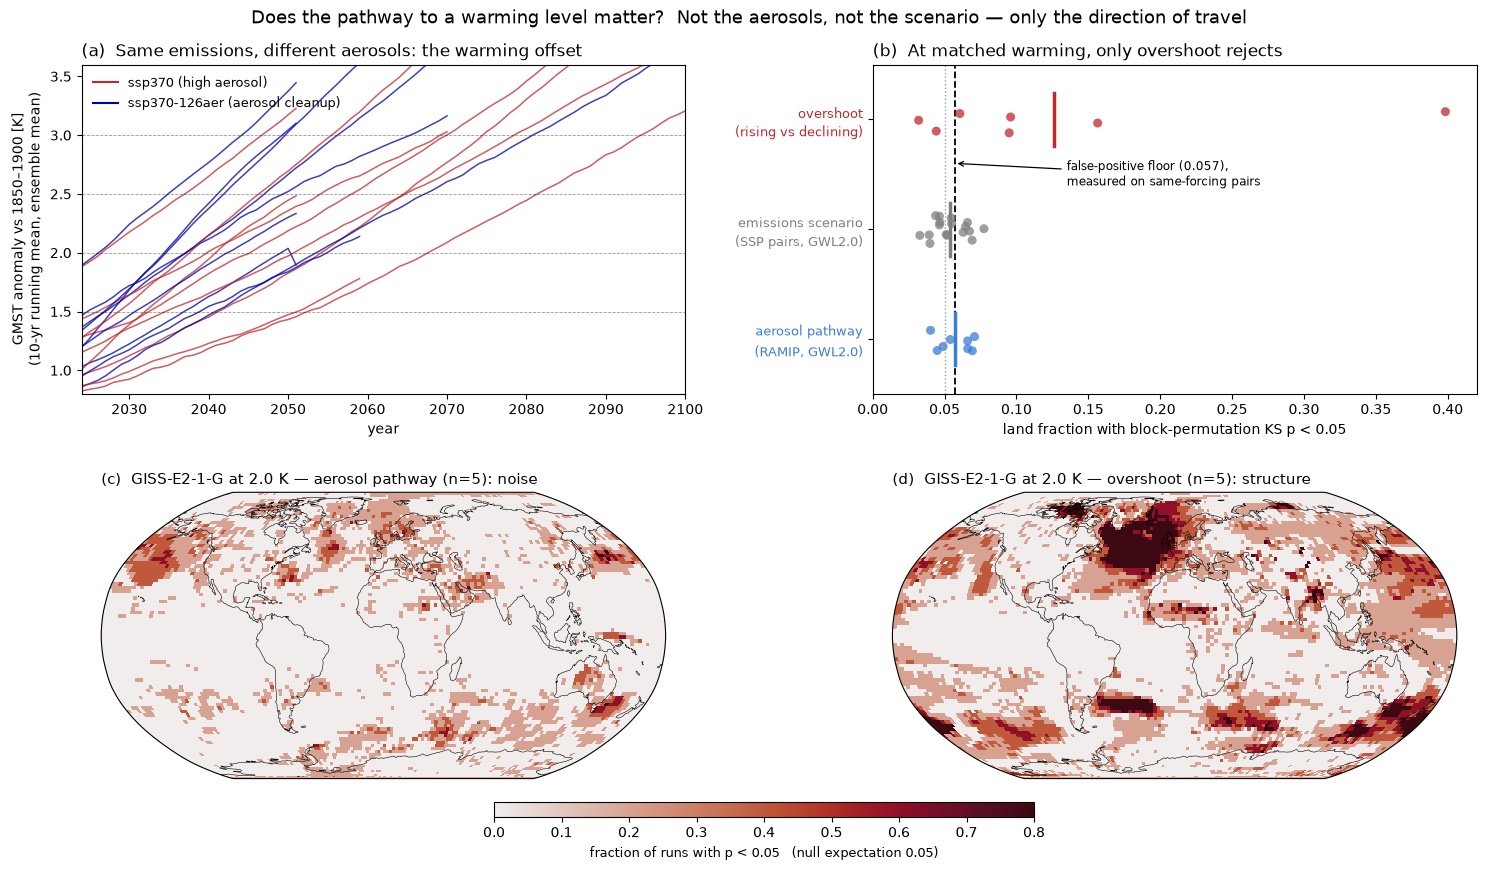

In [5]:
fig = plt.figure(figsize=(15, 8.5))
gs = gridspec.GridSpec(2, 4, height_ratios=[1.15, 1], hspace=0.32, wspace=0.9,
                       left=0.055, right=0.985, top=0.90, bottom=0.06)
ax_a = fig.add_subplot(gs[0, :2])
ax_b = fig.add_subplot(gs[0, 2:])
ax_c1 = fig.add_subplot(gs[1, :2], projection=ccrs.Robinson())
ax_c2 = fig.add_subplot(gs[1, 2:], projection=ccrs.Robinson())

# ---- (a) trajectories
for mod in models_a:
    ax_a.plot(traj[(mod, 'anchor')].year, traj[(mod, 'anchor')], color=RED, lw=1.1, alpha=0.75)
    ax_a.plot(traj[(mod, 'cleanup')].year, traj[(mod, 'cleanup')], color=BLUE, lw=1.1, alpha=0.75)
for g in [1.5, 2.0, 2.5, 3.0]:
    ax_a.axhline(g, color='k', ls='--', lw=0.6, alpha=0.4)
ax_a.set_xlim(2024, 2100)
ax_a.set_ylim(0.8, 3.6)
ax_a.set_ylabel('GMST anomaly vs 1850–1900 [K]\n(10-yr running mean, ensemble mean)')
ax_a.set_xlabel('year')
ax_a.plot([], [], color=RED, label='ssp370 (high aerosol)')
ax_a.plot([], [], color=BLUE, label='ssp370-126aer (aerosol cleanup)')
ax_a.legend(loc='upper left', fontsize=9, frameon=False)
ax_a.set_title('(a)  Same emissions, different aerosols: the warming offset', loc='left')

# ---- (b) land fractions by family
order = fam_df.family.unique()
cols = {order[0]: '#3b7dd8', order[1]: '#7f7f7f', order[2]: '#c1272d'}
rng = np.random.default_rng(3)
for i, fam in enumerate(order):
    v = fam_df[fam_df.family == fam].lf.values
    ax_b.scatter(v, i + rng.uniform(-0.13, 0.13, len(v)), s=42, color=cols[fam],
                 alpha=0.75, edgecolor='none', zorder=3)
    ax_b.plot([v.mean()] * 2, [i - 0.24, i + 0.24], color=cols[fam], lw=2.5, zorder=4)
ax_b.axvline(FLOOR, color='k', ls='--', lw=1.3, zorder=2)
ax_b.axvline(ALPHA, color='0.6', ls=':', lw=1, zorder=2)
ax_b.annotate(f'false-positive floor ({FLOOR}),\nmeasured on same-forcing pairs',
              xy=(FLOOR, 1.60), xytext=(0.135, 1.50), fontsize=8.5, va='center',
              arrowprops=dict(arrowstyle='->', lw=0.9))
ax_b.set_yticks(range(len(order)))
ax_b.set_yticklabels(order, fontsize=9.5, linespacing=1.5)
for lab, fam in zip(ax_b.get_yticklabels(), order):
    lab.set_color(cols[fam])
ax_b.set_xlabel(f'land fraction with block-permutation KS p < {ALPHA}')
ax_b.set_xlim(0, 0.42)
ax_b.set_ylim(-0.5, 2.5)
ax_b.set_title('(b)  At matched warming, only overshoot rejects', loc='left')

# ---- (c) the pair of maps
for ax, f, ttl in [(ax_c1, frac_ram, '(c)  GISS-E2-1-G at 2.0 K — aerosol pathway (n=5): noise'),
                   (ax_c2, frac_ove, '(d)  GISS-E2-1-G at 2.0 K — overshoot (n=5): structure')]:
    im = ax.pcolormesh(f.lon, f.lat, f, cmap=cmocean.cm.amp, vmin=0, vmax=0.8,
                       transform=ccrs.PlateCarree())
    ax.coastlines(lw=0.4)
    ax.set_title(ttl, loc='left', fontsize=10.5)
cax = fig.add_axes([0.33, 0.015, 0.36, 0.018])
cb = fig.colorbar(im, cax=cax, orientation='horizontal')
cb.set_label(f'fraction of runs with p < {ALPHA}   (null expectation {ALPHA})', fontsize=9)

fig.suptitle('Does the pathway to a warming level matter?  '
             'Not the aerosols, not the scenario — only the direction of travel',
             fontsize=13, y=0.965)
fig.savefig(out_dir + 'project_overview.png', dpi=180, bbox_inches='tight')
print('saved', out_dir + 'project_overview.png')